This notebook rebuilds `visualize_mass_results2.ipynb` with reusable helpers so new model comparisons only require small configuration edits.
- Load experiment JSON artifacts once.
- Define groups of runs and call plotting helpers instead of copying plotting code.

In [1]:
from collections import OrderedDict
from pathlib import Path
from typing import Callable, Dict, Mapping, Optional, Sequence, Tuple

import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.35,
    "figure.figsize": (9, 5)
})

In [8]:
DATA_ROOT = Path("info")

def load_json(path: Path) -> Dict:
    with open(path, "r") as handle:
        return json.load(handle)

non_cnn = load_json(DATA_ROOT / "non_cnn_analysis.json")
cnn = load_json(DATA_ROOT / "cnn_analysis_results.json")
cnn_v2 = load_json(DATA_ROOT / "cnn_analysis_results2.json")
cnn_rand = load_json(DATA_ROOT / "cnn_analysis_results_orth_rand.json")

DATASETS = {
    "mlp_orth": non_cnn["mlp\\orth"],
    "mlp_orth_rand": non_cnn["mlp\\orth rand"],
    "mlp_LA": non_cnn["mlp\\LA"],
    "linear_orth": non_cnn["linear\\orth"],
    "linear_LA": non_cnn["linear\\LA"],
    "cnn_orth": cnn["cnn\\orth"],
    "cnn_orth_new": cnn_v2["cnn\\orth new"],
    # "cnn_LA": cnn_v2["cnn\\LA"],
    "cnn_orth_rand": cnn_rand["cnn\\orth rand"]
}

## Helper Utilities
Reusable plotting and extraction helpers replace the repeated code blocks from the previous notebook.

In [12]:
COLOR_PALETTE = sns.color_palette("tab10", 12)
COLOR_REGISTRY = {"Initial Contrast": "#111111"}

def color_for(label: str):
    if label not in COLOR_REGISTRY:
        COLOR_REGISTRY[label] = COLOR_PALETTE[len(COLOR_REGISTRY) % len(COLOR_PALETTE)]
    return COLOR_REGISTRY[label]

def log_to_linear(values: np.ndarray) -> np.ndarray:
    return np.power(10.0, np.asarray(values, dtype=float))

def get_array(stats: Mapping, *keys: str) -> np.ndarray:
    node = stats
    for key in keys:
        node = node[key]
    return np.asarray(node, dtype=float)

def collect_stats(group: Mapping[str, Mapping], stats_key: str, *, strict: bool = False) -> Dict[str, Mapping]:
    stats_map: Dict[str, Mapping] = {}
    missing = []
    for label, model in group.items():
        if stats_key in model:
            stats_map[label] = model[stats_key]
        else:
            missing.append(label)
    if missing:
        message = f"Missing '{stats_key}' for: {', '.join(missing)}"
        if strict:
            raise KeyError(message)
        print(f"[info] {message}")
    return stats_map

def get_axis(stats_map: Mapping[str, Mapping], axis_key: str) -> np.ndarray:
    if not stats_map:
        raise ValueError("No stats available to infer axis.")
    first = next(iter(stats_map.values()))
    return np.asarray(first[axis_key], dtype=float)

def find_axis_index(axis: Sequence[float], target: float) -> Tuple[int, float]:
    axis_arr = np.asarray(axis, dtype=float)
    idx = int(np.argmin(np.abs(axis_arr - target)))
    return idx, float(axis_arr[idx])

def build_metric_dict(stats_map: Mapping[str, Mapping], key_path: Sequence[str], transform: Optional[Callable[[np.ndarray], np.ndarray]] = None) -> Dict[str, np.ndarray]:
    metric = {}
    for label, stats in stats_map.items():
        values = get_array(stats, *key_path)
        metric[label] = transform(values) if transform else values
    return metric

def log_std_to_linear_error(log_mean: float, log_std: float) -> Tuple[float, float]:
    base = 10 ** log_mean
    lower = base - 10 ** (log_mean - log_std)
    upper = 10 ** (log_mean + log_std) - base
    return lower, upper

def compute_log_errors(stats_map: Mapping[str, Mapping], mean_path: Sequence[str], std_path: Sequence[str], idx: int) -> Dict[str, Tuple[float, float]]:
    errors: Dict[str, Tuple[float, float]] = {}
    for label, stats in stats_map.items():
        log_mean = get_array(stats, *mean_path)[idx]
        log_std = get_array(stats, *std_path)[idx]
        errors[label] = log_std_to_linear_error(log_mean, log_std)
    return errors

def plot_curve_series(x_values: Sequence[float], series_dict: Mapping[str, np.ndarray], title: str, ylabel: str, xlabel: str, *, xscale: str = "linear", yscale: str = "linear", reference: Optional[float] = None, reference_label: str = "Reference") -> None:
    plt.figure()
    markers = ["o", "s", "^", "d", "v", "P", "*", "X", "<", ">"]

    for label, values in series_dict.items():
        plt.plot(x_values, values, marker=markers[len(COLOR_REGISTRY) % len(markers)], label=label, color=color_for(label))
    if reference is not None:
        plt.axvline(reference, color="#444444", linestyle=":", linewidth=2.0, label=reference_label)
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.show()

def plot_bar_at_index(series_dict: Mapping[str, np.ndarray], idx: int, title: str, ylabel: str, *, yscale: str = "linear", errors: Optional[Mapping[str, Tuple[float, float]]] = None) -> None:
    labels = list(series_dict.keys())
    heights = [series_dict[label][idx] for label in labels]
    colors = [color_for(label) for label in labels]
    yerr = None
    if errors:
        yerr = np.array([errors[label] for label in labels]).T
    plt.figure()
    plt.bar(labels, heights, color=colors, yerr=yerr, capsize=6)
    plt.yscale(yscale)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=20)
    plt.show()

def plot_contrast_bar_summary(stats_map: Mapping[str, Mapping], noise_value: float, title: str, ylabel: str = "Final Contrast") -> None:
    axis = get_axis(stats_map, "noise_levels")
    idx, actual = find_axis_index(axis, noise_value)
    curves = build_metric_dict(stats_map, ("final_contrast_log10", "mean"), transform=log_to_linear)
    errors = compute_log_errors(stats_map, ("final_contrast_log10", "mean"), ("final_contrast_log10", "std"), idx)
    plot_bar_at_index(curves, idx, f"{title} (noise={actual:.2e})", ylabel, yscale="log", errors=errors)

def plot_final_contrast_curves(stats_map: Mapping[str, Mapping], title: str, train_noise: Optional[float], include_initial: bool = True) -> None:
    axis = get_axis(stats_map, "noise_levels")
    curves = build_metric_dict(stats_map, ("final_contrast_log10", "mean"), transform=log_to_linear)
    if include_initial:
        initial = log_to_linear(get_array(next(iter(stats_map.values())), "initial_contrast_log10", "mean"))
        curves = {**curves, "Initial Contrast": initial}
    plot_curve_series(axis, curves, title, "Final Contrast", "Noise Level", xscale="log", yscale="log", reference=train_noise, reference_label="Training Noise Level")

def plot_cosine_curves(stats_map: Mapping[str, Mapping], title: str, train_noise: Optional[float]) -> None:
    axis = get_axis(stats_map, "noise_levels")
    plt.figure()
    for label, stats in stats_map.items():
        mean = get_array(stats, "cosine_similarity", "mean")
        lower = get_array(stats, "cosine_similarity", "p25")
        upper = get_array(stats, "cosine_similarity", "p75")
        color = color_for(label)
        plt.plot(axis, mean, marker="o", label=label, color=color)
        plt.fill_between(axis, lower, upper, color=color, alpha=0.15)
    if train_noise is not None:
        plt.axvline(train_noise, color="#444444", linestyle=":", linewidth=2.0, label="Training Noise Level")
    plt.xscale("log")
    plt.xlabel("Noise Level")
    plt.ylabel("Cosine Similarity")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.show()

def plot_metric_curve(stats_map: Mapping[str, Mapping], axis_key: str, metric_path: Sequence[str], title: str, xlabel: str, ylabel: str, *, transform: Optional[Callable[[np.ndarray], np.ndarray]] = None, xscale: str = "linear", yscale: str = "linear", reference: Optional[float] = None, reference_label: str = "Reference") -> None:
    if not stats_map:
        print("[info] No stats available for plot.")
        return
    axis = get_axis(stats_map, axis_key)
    series = build_metric_dict(stats_map, metric_path, transform=transform)
    plot_curve_series(axis, series, title, ylabel, xlabel, xscale=xscale, yscale=yscale, reference=reference, reference_label=reference_label)

def plot_pre_post_contrast(pre_stats: Mapping[str, Mapping], post_stats: Mapping[str, Mapping], noise_value: float, title: str, ylabel: str = "Final Contrast") -> None:
    axis_pre = get_axis(pre_stats, "noise_levels")
    idx_pre, noise_actual = find_axis_index(axis_pre, noise_value)
    axis_post = get_axis(post_stats, "noise_levels")
    idx_post, _ = find_axis_index(axis_post, noise_actual)
    pre_curves = build_metric_dict(pre_stats, ("final_contrast_log10", "mean"), transform=log_to_linear)
    post_curves = build_metric_dict(post_stats, ("final_contrast_log10", "mean"), transform=log_to_linear)
    labels = list(post_curves.keys())
    x = np.arange(len(labels))
    width = 0.35
    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, [pre_curves[label][idx_pre] for label in labels], width, label="Ordinary", color=[color_for(label) for label in labels], alpha=0.6)
    plt.bar(x + width / 2, [post_curves[label][idx_post] for label in labels], width, label="Unbiased", color=[color_for(label) for label in labels], alpha=0.9)
    plt.yscale("log")
    plt.xticks(x, labels, rotation=20)
    plt.ylabel(ylabel)
    plt.title(f"{title} (noise={noise_actual:.2e})")
    plt.legend()
    plt.show()

## Model Group Catalog
Edit the catalog below to wire new experiments into the helper pipeline.

In [13]:
MODEL_GROUPS = {
    "Orth Baseline": OrderedDict({
        "Linear Model": DATASETS["linear_orth"]["exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images"],
        "Small MLP": DATASETS["mlp_orth"]["exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images"],
        "Large MLP": DATASETS["mlp_orth"]["exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images"],
        "CNN": DATASETS["cnn_orth_new"]["exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images"],
        "Small CNN": DATASETS["cnn_orth_new"]["exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small"]
    }),
    "Orth Random Init": OrderedDict({
        "Linear Model": DATASETS["linear_orth"]["exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images"],
        "Small MLP (rand init)": DATASETS["mlp_orth_rand"]["exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images"],
        "Large MLP (rand init)": DATASETS["mlp_orth_rand"]["exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images"],
        "CNN": DATASETS["cnn_orth_new"]["exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images"],
        "Small CNN": DATASETS["cnn_orth_new"]["exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small"],
        "CNN (rand init)": DATASETS["cnn_orth_rand"]["exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images"],
        "Small CNN (rand init)": DATASETS["cnn_orth_rand"]["exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small"]
    }),
    "LA Regularization": OrderedDict({
        "Large MLP (weight decay)": DATASETS["mlp_LA"]["exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005"],
        "Large MLP (dropout)": DATASETS["mlp_LA"]["exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.2"],
        "Linear Model": DATASETS["linear_LA"]["exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images"],
        # "CNN": DATASETS["cnn_LA"]["exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h128-64-images"],
        # "CNN (wd + dropout)": DATASETS["cnn_LA"]["exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h128-64-images-wd0.0005-do0.1"]
    })
}

TRAIN_NOISE = {
    "Orth Baseline": 1e-7,
    "Orth Random Init": 1e-7,
    "LA Regularization": 1e-6
}

NOISE_MODE_REFERENCE = 25

## Orth Baseline — Exp1 Summary

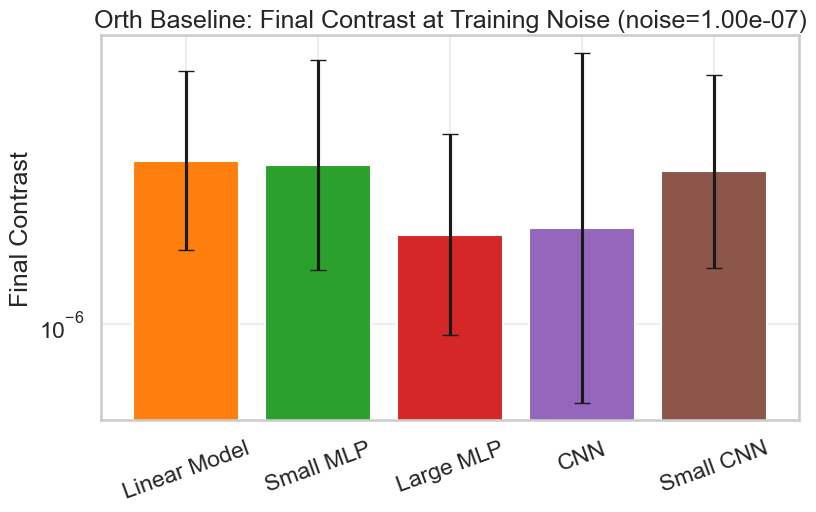

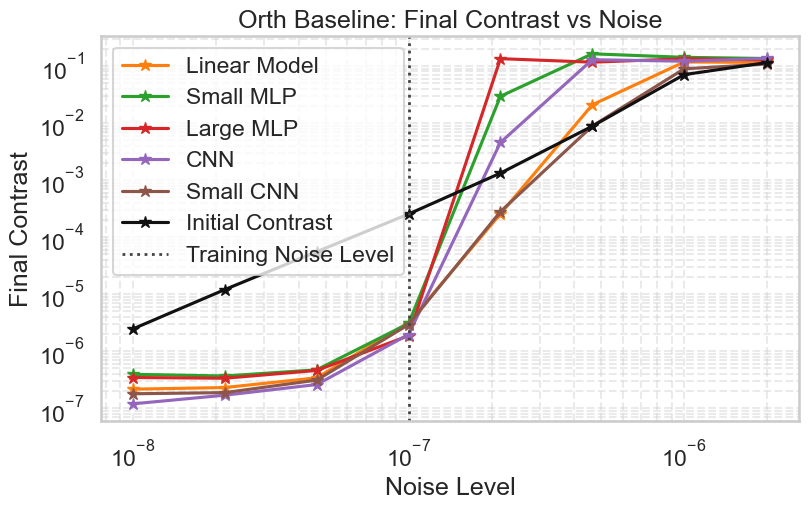

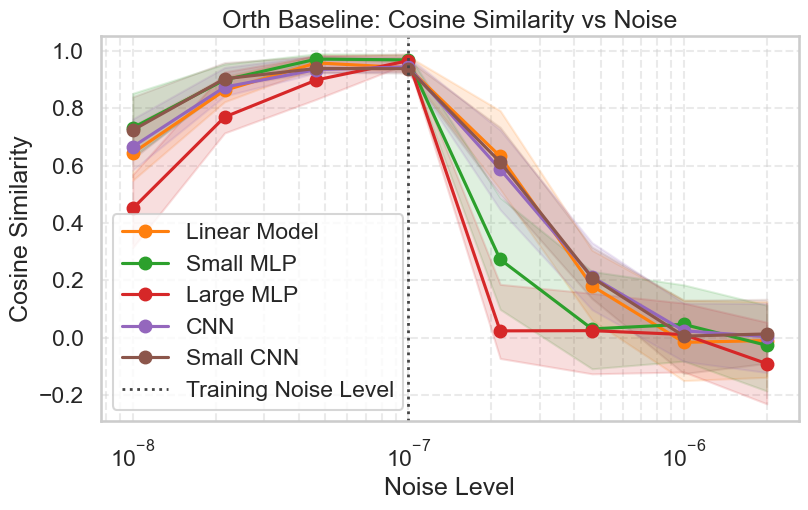

In [14]:
group = "Orth Baseline"
train_noise = TRAIN_NOISE[group]
exp1_stats = collect_stats(MODEL_GROUPS[group], "exp1 evaluation stats")

plot_contrast_bar_summary(exp1_stats, noise_value=train_noise, title=f"{group}: Final Contrast at Training Noise")
plot_final_contrast_curves(exp1_stats, title=f"{group}: Final Contrast vs Noise", train_noise=train_noise)
plot_cosine_curves(exp1_stats, title=f"{group}: Cosine Similarity vs Noise", train_noise=train_noise)

### Orth Baseline — Stress Tests (Exp2 & Exp3)

In [ ]:
exp2_stats = collect_stats(MODEL_GROUPS[group], "exp2 evaluation stats")
if exp2_stats:
    plot_metric_curve(exp2_stats, axis_key="noise_mode_amounts", metric_path=("final_contrast_log10", "mean"), transform=log_to_linear, title=f"{group}: Final Contrast vs Added Noise Modes", xlabel="Number of Noise Modes Added", ylabel="Final Contrast", xscale="log", yscale="log", reference=NOISE_MODE_REFERENCE, reference_label="Training Noise Modes")
    plot_metric_curve(exp2_stats, axis_key="noise_mode_amounts", metric_path=("cosine_similarity", "mean"), title=f"{group}: Cosine Similarity vs Added Noise Modes", xlabel="Number of Noise Modes Added", ylabel="Cosine Similarity", xscale="log", reference=NOISE_MODE_REFERENCE, reference_label="Training Noise Modes")
else:
    print("No exp2 evaluation stats for this group.")

exp3_stats = collect_stats(MODEL_GROUPS[group], "exp3 evaluation stats")
if exp3_stats:
    plot_metric_curve(exp3_stats, axis_key="noise_levels", metric_path=("final_contrast_log10", "mean"), transform=log_to_linear, title=f"{group}: Final Contrast vs Noise Level (7 iterations)", xlabel="Noise Level", ylabel="Final Contrast", xscale="log", yscale="log", reference=train_noise, reference_label="Training Noise Level")
else:
    print("No exp3 evaluation stats for this group.")

## Orth Random Init — Summary & Convergence

In [ ]:
group = "Orth Random Init"
train_noise = TRAIN_NOISE[group]
rand_exp1_stats = collect_stats(MODEL_GROUPS[group], "exp1 evaluation stats")

plot_contrast_bar_summary(rand_exp1_stats, noise_value=train_noise, title=f"{group}: Final Contrast at Training Noise")
plot_final_contrast_curves(rand_exp1_stats, title=f"{group}: Final Contrast vs Noise", train_noise=train_noise)
plot_cosine_curves(rand_exp1_stats, title=f"{group}: Cosine Similarity vs Noise", train_noise=train_noise)

available_for_convergence = OrderedDict((label, run) for label, run in MODEL_GROUPS[group].items() if "convergence_stats" in run)
rand_conv_stats = collect_stats(available_for_convergence, "convergence_stats")
if rand_conv_stats:
    plot_contrast_bar_summary(rand_conv_stats, noise_value=train_noise, title=f"{group}: Unbiased Final Contrast", ylabel="Final Contrast (unbiased)")
    plot_pre_post_contrast(rand_exp1_stats, rand_conv_stats, noise_value=train_noise, title=f"{group}: Ordinary vs Unbiased Contrast")
else:
    print("No convergence stats available for this group.")

## LA Regularization — Exp1

In [ ]:
group = "LA Regularization"
train_noise = TRAIN_NOISE[group]
la_exp1_stats = collect_stats(MODEL_GROUPS[group], "exp1 evaluation stats")

plot_contrast_bar_summary(la_exp1_stats, noise_value=train_noise, title=f"{group}: Final Contrast at Training Noise")
plot_final_contrast_curves(la_exp1_stats, title=f"{group}: Final Contrast vs Noise", train_noise=train_noise)
plot_cosine_curves(la_exp1_stats, title=f"{group}: Cosine Similarity vs Noise", train_noise=train_noise)